In [9]:
import pickle
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = Path('/global/home/users/ann_scheliga/neuralhydrology/runs/')
exp_name = 'EXP00'

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

quick_eval tuple order: sw_train_results, nosw_train_results, sw_test_results, nosw_test_results

In [3]:
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

In [4]:
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()
exp_runs

['EXP00_no_sw_MSE_10basin_2208_195941',
 'EXP00_no_sw_NSE_10basin_2508_093119',
 'EXP00_wi_sw_MSE_10basin_2508_091637',
 'EXP00_wi_sw_NSE_10basin_2508_094527']

In [5]:
mse_run_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP00_no_sw_MSE_10basin_2208_195941',
    fp_wi_sw='EXP00_wi_sw_MSE_10basin_2508_091637',
    run_dir = all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_wi_sw_MSE_10basin_2508_091637
# Validation: 100%|██████████| 10/10 [00:04<00:00,  2.42it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_wi_sw_MSE_10basin_2508_091637
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_MSE_10basin_2208_195941
# Validation: 100%|██████████| 10/10 [00:01<00:00,  7.20it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_MSE_10basin_2208_195941
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500'

In [6]:
nse_run_metrics = eval_wrapper.quick_eval(fp_no_sw='EXP00_no_sw_NSE_10basin_2508_093119',
    fp_wi_sw='EXP00_wi_sw_NSE_10basin_2508_094527',
    run_dir = all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_wi_sw_NSE_10basin_2508_094527
# Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/1159302_p.k._le_roux.pkl')]
# Validation: 100%|██████████| 10/10 [00:01<00:00,  5.84it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_wi_sw_NSE_10basin_2508_094527
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_NSE_10basin_2508_093119
# Validation: 100%|██████████| 10/10 [00:01<00:00,  7.71it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_NSE_10basin_2508_093119
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050',

(-1.5, 1.0)

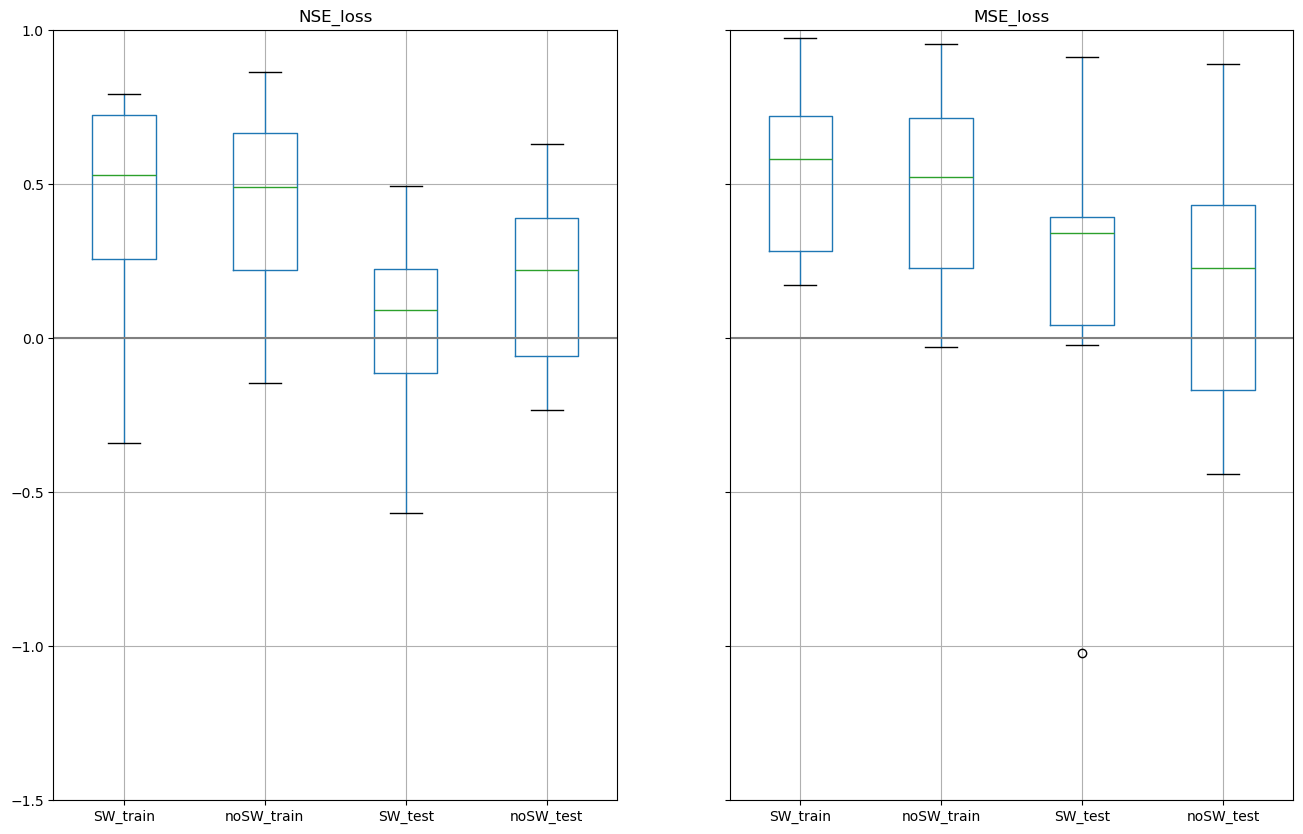

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10),sharey=True)
test = comp_plots.boxplot_from_tuple(nse_run_metrics,ax=axs[0],tuple_names=default_order,exp_name = 'NSE_loss')
test = comp_plots.boxplot_from_tuple(mse_run_metrics,ax=axs[1],tuple_names=default_order,exp_name = 'MSE_loss')
axs[0].set_ylim([-1.5,1])

,SW train,SW test,No SW train,No SW test
NSE,0.101586,-0.240892,-0.030871,-0.234191
MSE,132.174515,193.470291,151.661713,192.425644
RMSE,11.496718,13.909360,12.315101,13.871757
KGE,0.010024,-0.192650,-0.031062,-0.045420
Alpha-NSE,0.254980,0.406434,0.268899,0.434018
Beta-KGE,0.954083,1.103441,1.142483,1.186198
Beta-NSE,-0.108306,0.227842,0.336077,0.410126
Pearson-r,0.349701,-0.029268,0.287063,0.140990
FHV,-50.780060,-41.282906,-43.169422,-23.257883
FMS,-84.148506,-47.751801,-80.853096,-80.615685


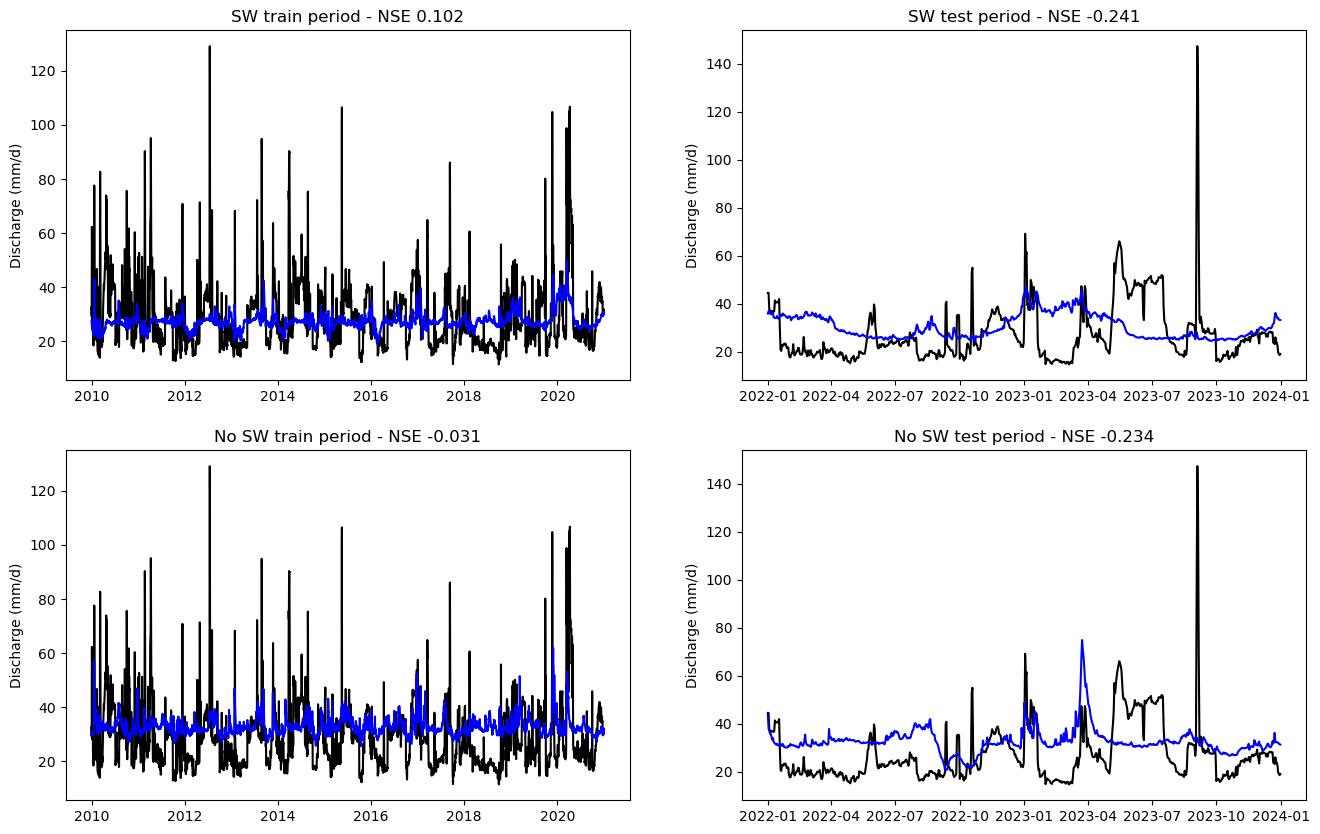

In [74]:
eval_wrapper.quick_basin_plot(*nse_run_metrics,
    basin_key = '4152050')

,SW train,SW test,No SW train,No SW test
NSE,-25.284644,-44.528117,-43.199234,-86.987228
MSE,3866.994873,7098.393066,6502.587402,13718.302734
RMSE,62.185166,84.251962,80.638622,117.125158
KGE,-2.378322,-3.582253,-3.031512,-5.046528
Alpha-NSE,3.950359,4.995379,4.293637,5.997327
Beta-KGE,2.351056,3.001397,3.164083,4.288332
Beta-NSE,3.186767,4.408337,5.104471,7.242981
Pearson-r,0.060270,-0.014100,0.150417,0.120177
FHV,172.916229,336.156464,234.978989,472.113556
FMS,6.544003,55.074795,26.100809,32.434177


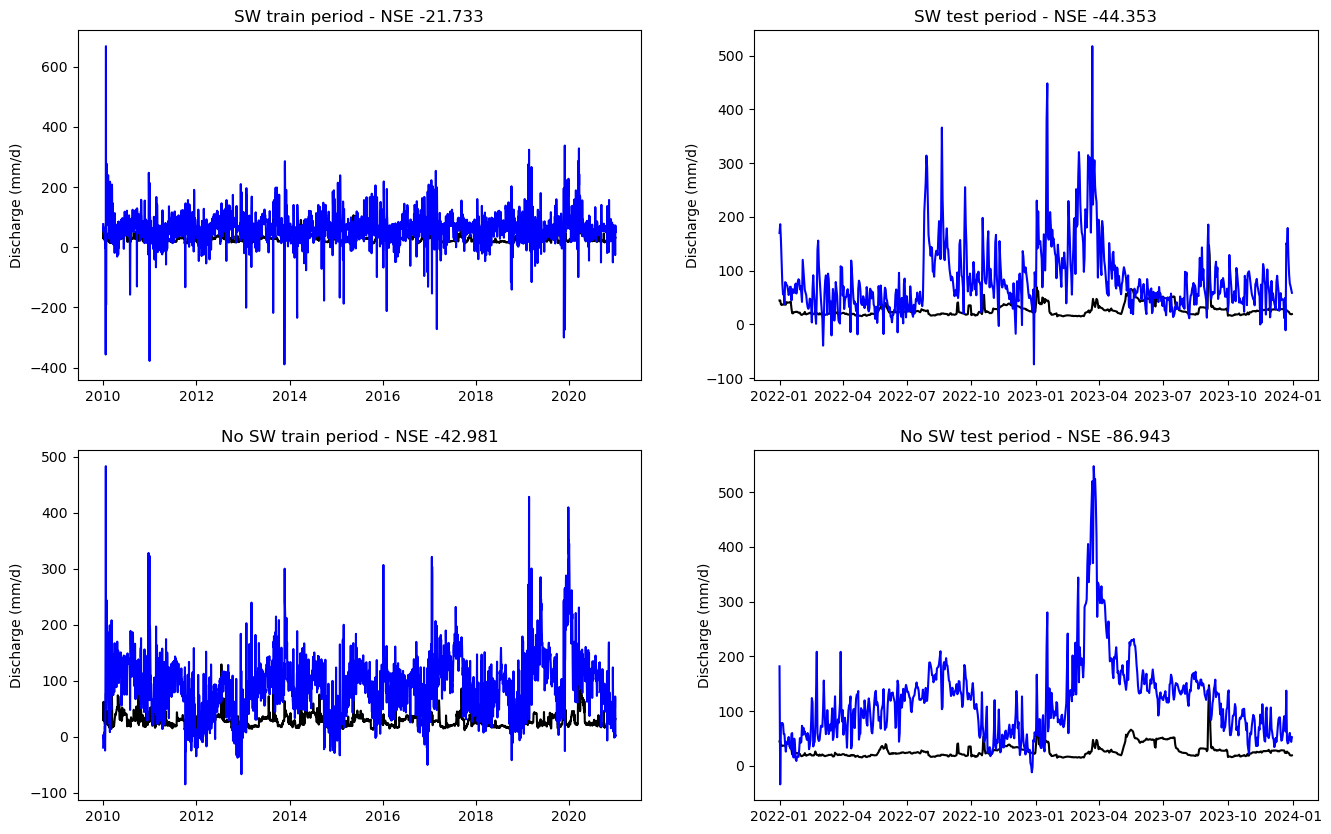

In [75]:
eval_wrapper.quick_basin_plot(*mse_run_metrics,
    basin_key = '4152050')